In [1]:
!pip install -q sentence-transformers fasttext openpyxl scikit-learn transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 4.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import pandas as pd
import numpy as np
import fasttext
import torch

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sentence_transformers import SentenceTransformer
from transformers import BertTokenizer, BertModel

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving agriculture.xlsx to agriculture.xlsx


In [ ]:
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

# Assumes columns: Word1, Word2, Label
word1_list = df['WORD1'].tolist()
word2_list = df['WORD2'].tolist()
true_labels = df['Similarity'].tolist()

In [ ]:
f# Load FastText model from Google Drive
ft_model = fasttext.load_model(
    '/content/drive/MyDrive/cc.ta.300.bin/cc.ta.300.bin'
)

# Load LaBSE
labse = SentenceTransformer('sentence-transformers/LaBSE')

# Load multilingual BERT (mBERT)
tokenizer_mbert = BertTokenizer.from_pretrained(
    'bert-base-multilingual-cased'
)

model_mbert = BertModel.from_pretrained(
    'bert-base-multilingual-cased'
)

model_mbert.eval()

print("All models loaded successfully.")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(119547, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=Fals

In [ ]:
import numpy as np
from numpy.linalg import norm

# 🧮 Define similarity functions
def cosine_sim(a, b):
    return np.dot(a, b) / (norm(a) * norm(b) + 1e-8)

def euclidean_sim(a, b):
    return 1 / (1 + norm(a - b))

# 🧾 Extract word pairs from your DataFrame
word1_list = df["WORD1"].tolist()
word2_list = df["WORD2"].tolist()
similarity_labels = df["Similarity"].tolist()

# 🔁 Containers for all similarity values
ft_cos, ft_euc = [], []
mbert_cos, mbert_euc = [], []
labse_cos, labse_euc = [], []

# 🔁 Compute similarities for each model
for w1, w2 in zip(word1_list, word2_list):
    # ----- FastText -----
    try:
        v1 = ft_model.get_word_vector(w1)
        v2 = ft_model.get_word_vector(w2)
        ft_cos.append(cosine_sim(v1, v2))
        ft_euc.append(euclidean_sim(v1, v2))
    except:
        ft_cos.append(0)
        ft_euc.append(0)

    # ----- mBERT (mean pooling over token embeddings) -----
    try:
        with torch.no_grad():
            t1 = tokenizer_mbert(w1, return_tensors="pt", padding=True, truncation=True)
            t2 = tokenizer_mbert(w2, return_tensors="pt", padding=True, truncation=True)
            emb1 = model_mbert(**t1).last_hidden_state.mean(dim=1).squeeze().numpy()
            emb2 = model_mbert(**t2).last_hidden_state.mean(dim=1).squeeze().numpy()
        mbert_cos.append(cosine_sim(emb1, emb2))
        mbert_euc.append(euclidean_sim(emb1, emb2))
    except:
        mbert_cos.append(0)
        mbert_euc.append(0)

    # ----- LaBSE (direct vector from SentenceTransformer) -----
    try:
        emb1 = labse.encode(w1)
        emb2 = labse.encode(w2)
        labse_cos.append(cosine_sim(emb1, emb2))
        labse_euc.append(euclidean_sim(emb1, emb2))
    except:
        labse_cos.append(0)
        labse_euc.append(0)

In [ ]:
df_result = pd.DataFrame({
    'Word1': word1_list,
    'Word2': word2_list,
    'Label': true_labels,
    'FastText_Cosine': ft_cos,
    'FastText_Euclidean':ft_euc,
    'mBERT_Cosine': mbert_cos,
    'mBERT_Euclidean': mbert_euc,
    'LaBSE_Cosine':labse_cos,
    'LaBSE_Euclidean': labse_euc,
})


In [ ]:
# Save the full result DataFrame to Excel
df_result.to_excel("final_similarity_results(agri).xlsx", index=False)

# Download the Excel file to your system
from google.colab import files
files.download("final_similarity_results(agri).xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

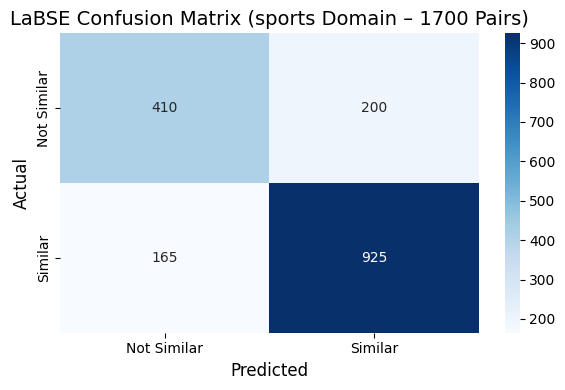

In [ ]:
# LaBSE confusion matrix

cm = confusion_matrix(
    df_result['Label'],
    df_result['labse_pred']
)

labels = ["Not Similar", "Similar"]

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("LaBSE Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
threshold = 0.5

# Generate predicted labels from scores
df_result['fasttext_pred'] = [1 if s >= threshold else 0 for s in df_result['FastText_Cosine']]
df_result['mbert_pred'] = [1 if s >= threshold else 0 for s in df_result['mBERT_Cosine']]
df_result['labse_pred'] = [1 if s >= threshold else 0 for s in df_result['LaBSE_Cosine']]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"📌 {model_name}")
    print(f"✅ Accuracy:  {acc:.4f}")
    print(f"✅ Precision: {prec:.4f}")
    print(f"✅ Recall:    {rec:.4f}")
    print(f"✅ F1 Score:  {f1:.4f}\n")

# Ground truth
y_true = df_result['Label']  # change to 'Similarity' only if your file uses that

# Evaluate predictions
evaluate_model(y_true, df_result['fasttext_pred'], "FastText (Cosine)")
evaluate_model(y_true, df_result['mbert_pred'], "mBERT")
evaluate_model(y_true, df_result['labse_pred'], "LaBSE")


📌 FastText (Cosine)
✅ Accuracy:  0.6103
✅ Precision: 0.8607
✅ Recall:    0.4688
✅ F1 Score:  0.6069

📌 mBERT
✅ Accuracy:  0.6562
✅ Precision: 0.6844
✅ Recall:    0.8616
✅ F1 Score:  0.7628

📌 LaBSE
✅ Accuracy:  0.7851
✅ Precision: 0.8225
✅ Recall:    0.8482
✅ F1 Score:  0.8352



In [ ]:
df_result = pd.DataFrame({
    'Word1': word1_list,
    'Word2': word2_list,
    'Label': true_labels,
    'FastText_Cosine': ft_cos,
    'FastText_Euclidean':ft_euc,
    'mBERT_Cosine': mbert_cos,
    'mBERT_Euclidean': mbert_euc,
    'LaBSE_Cosine':labse_cos,
    'LaBSE_Euclidean': labse_euc,
})

# Top 5 similar and bottom 5 dissimilar (mBERT)
top5 = df_result.sort_values(by="mBERT_Cosine", ascending=False).head(5)
bottom5 = df_result.sort_values(by="mBERT_Cosine", ascending=True).head(5)

print("Top 5 Most Similar (mBERT):\n", top5[['Word1', 'Word2', 'mBERT_Cosine']])
print("\nBottom 5 Most Dissimilar (mBERT):\n", bottom5[['Word1', 'Word2', 'mBERT_Cosine']])


Top 5 Most Similar (mBERT):
              Word1         Word2  mBERT_Cosine
327      மனரீதியான     உளரீதியான      0.904524
216  weightlifting  powerlifting      0.895937
50         victory           win      0.867416
159   martial arts  combat  arts      0.863805
126  penality kick     spot kick      0.851827

Bottom 5 Most Dissimilar (mBERT):
              Word1      Word2  mBERT_Cosine
149         sprint     recipe      0.296641
185  entertainment  diversion      0.298257
151          match      email      0.300530
61          sprint       dash      0.302165
251         runner    swimmer      0.307086


In [ ]:
top15_all = df_result.sort_values(by="LaBSE_Cosine", ascending=False).head(10)
top15_all.to_excel("top15_results_domain.xlsx", index=False)

from google.colab import files
files.download("top15_results_domain.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>